In [2]:
import torchvision
import torchvision.transforms as transforms
import tarfile
import os

# Ensure the data directory exists
os.makedirs('./data', exist_ok=True)

# Path to the local dataset archive (adjust path if running from a different root)
archive_path = 'cifar-10-python.tar.gz'
if not os.path.exists(archive_path):
    archive_path = 'anomaly/cifar-10-python.tar.gz'

# Extract the dataset if not already extracted
if not os.path.exists('./data/cifar-10-batches-py') and os.path.exists(archive_path):
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(path='./data')
    print("Dataset extracted locally.")

# Transform to convert images to PyTorch tensors
transform = transforms.Compose([transforms.ToTensor()])

# Load the CIFAR-10 training dataset locally (no download)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)

# Load the CIFAR-10 test dataset locally (no download)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

print(f"Training set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")

Dataset extracted locally.


c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training set size: 50000
Test set size: 10000


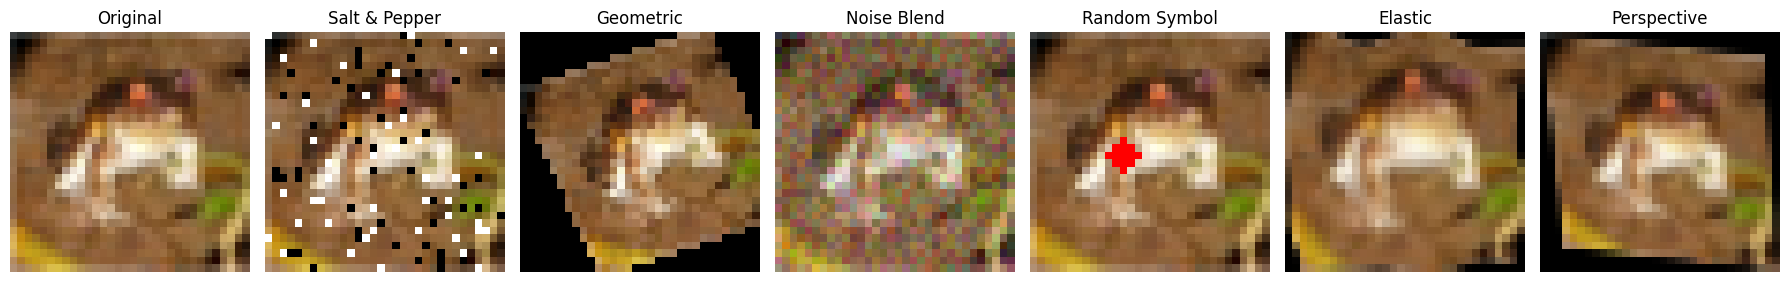

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

def add_salt_and_pepper(img, prob=0.05):
    """Adds salt and pepper noise to an image tensor."""
    noisy = img.clone()
    _, h, w = noisy.shape
    # Generate random matrix for probability
    rand = torch.rand(1, h, w)
    
    # Apply pepper (0) and salt (1)
    noisy[:, rand[0] < prob / 2] = 0.0 
    noisy[:, rand[0] > 1 - prob / 2] = 1.0 
    return noisy

def add_geometric_distortion(img):
    """Applies a random affine geometric distortion."""
    distorter = transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=15)
    return distorter(img)

def blend_with_noise(img, alpha=0.3):
    """Blends the image with uniform noise using proportion alpha."""
    noise = torch.rand_like(img)
    blended = (1 - alpha) * img + alpha * noise
    return torch.clamp(blended, 0.0, 1.0)

def add_random_symbol(img, radius=3):
    """Adds a small symbol (a red circle) at a random position."""
    symbol_img = img.clone()
    c, h, w = symbol_img.shape
    
    # Choose random center ensuring the circle fits in the image
    x = np.random.randint(radius, w - radius)
    y = np.random.randint(radius, h - radius)
    
    # Create circular binary mask
    Y, X = np.ogrid[:h, :w]
    dist_sq = (X - x)**2 + (Y - y)**2
    mask = dist_sq <= radius**2
    
    # Apply red color to the masked area
    symbol_img[0, mask] = 1.0  # R
    symbol_img[1, mask] = 0.0  # G
    symbol_img[2, mask] = 0.0  # B
    return symbol_img

def add_elastic_transform(img):
    """Applies an elastic transform to the image."""
    # alpha dictates the displacement severity; sigma dictates smoothness
    distorter = transforms.ElasticTransform(alpha=30.0, sigma=3.0)
    return distorter(img)

def add_random_perspective(img):
    """Applies a random perspective transformation."""
    distorter = transforms.RandomPerspective(distortion_scale=0.4, p=1.0)
    return distorter(img)

# Visualize the anomalies to verify implementation
def show_images(original, anomalies, titles):
    fig, axes = plt.subplots(1, len(anomalies) + 1, figsize=(18, 3))
    
    # Display Original
    axes[0].imshow(original.permute(1, 2, 0).numpy())
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    # Display each contamination type
    for ax, img, title in zip(axes[1:], anomalies, titles):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(title)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Get a sample image from the already loaded trainset
sample_img, _ = trainset[0]

# Apply all contamination methods
img_sp = add_salt_and_pepper(sample_img, prob=0.1)
img_geo = add_geometric_distortion(sample_img)
img_blend = blend_with_noise(sample_img, alpha=0.2)
img_symbol = add_random_symbol(sample_img, radius=2)
img_elastic = add_elastic_transform(sample_img)
img_perspective = add_random_perspective(sample_img)

# Plot everything
show_images(
    sample_img, 
    [img_sp, img_geo, img_blend, img_symbol, img_elastic, img_perspective], 
    ["Salt & Pepper", "Geometric", "Noise Blend", "Random Symbol", "Elastic", "Perspective"]
)

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl

class BinaryAnomalyDataset(Dataset):
    """
    Custom wrapper dataset that duplicates the given dataset:
    - First half is clean (label 0).
    - Second half is corrupted with salt & pepper noise (label 1).
    """
    def __init__(self, base_dataset, prob=0.05):
        self.base_dataset = base_dataset
        self.prob = prob
        
    def __len__(self):
        return len(self.base_dataset) * 2
        
    def __getitem__(self, idx):
        is_corrupted = idx >= len(self.base_dataset)
        base_idx = idx % len(self.base_dataset)
        img, _ = self.base_dataset[base_idx]
        
        if is_corrupted:
            img = add_salt_and_pepper(img, prob=self.prob)
            label = torch.tensor([1.0], dtype=torch.float32) # Corrupted
        else:
            label = torch.tensor([0.0], dtype=torch.float32) # Clean
            
        return img, label

# Create Datasets and DataLoaders
# We use prob=0.05 as default, but you can adjust this.
full_train_binary_set = BinaryAnomalyDataset(trainset, prob=0.05)
test_binary_set = BinaryAnomalyDataset(testset, prob=0.05)

# Split the full training set into training (80%) and validation (20%) sets
train_size = int(0.8 * len(full_train_binary_set))
val_size = len(full_train_binary_set) - train_size
train_binary_set, val_binary_set = random_split(full_train_binary_set, [train_size, val_size])

# Setting number of workers to 0 for Windows compatibility; feel free to increase this if using Linux/macOS
num_workers = 0 

trainloader = DataLoader(train_binary_set, batch_size=64, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_binary_set, batch_size=64, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_binary_set, batch_size=64, shuffle=False, num_workers=num_workers)

# Define a LightningModule for binary classification
class LitAnomalyClassifier(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 1) # Single output for binary classification
        self.criterion = nn.BCEWithLogitsLoss()
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
        
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss
        
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y).float().mean()
        
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=0.001)

# Initialize model
model = LitAnomalyClassifier()

# Initialize PyTorch Lightning Trainer
# accelerator='auto' will automatically pick CUDA/GPU if available, or fallback to CPU
trainer = pl.Trainer(
    max_epochs=3,
    accelerator="auto",
    devices=1,
    enable_progress_bar=True
)

# Run Training
print("Starting Training...")
trainer.fit(model, trainloader, val_dataloaders=valloader)

# Run Testing
print("Starting Evaluation...")
trainer.test(model, dataloaders=testloader)